<a href="https://colab.research.google.com/github/Joaopauloqz15/PUCRIO-Machine-Learning/blob/main/MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _JOÃO PAULO DO ESPÍRITO SANTO QUEIROZ_  
**Matrícula:** _05/07/2026_  
**Dataset:** CDC Diab/etes Health Indicators (BRFSS 2015)

**Fonte original:** https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

**Arquivo utilizado no notebook:** "https://raw.githubusercontent.com/Joaopauloqz15/PUCRIO-Machine-Learning/refs/heads/main/MVP01/dataset/diabetes_012_health_indicators_BRFSS2015.csv"

**Tipo de problema:** _Classificação_
---



## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

O diabetes é uma das doenças crônicas que mais cresce no mundo e pode causar diversas complicações quando não é identificado e tratado de forma adequada. Por isso, identificar pessoas com maior probabilidade de desenvolver a doença pode contribuir para ações de prevenção, acompanhamento e promoção da saúde.

Neste trabalho foi desenvolvido um modelo de Machine Learning com o objetivo de classificar indivíduos em três grupos: Sem Diabetes, Pré-diabetes e Diabetes, utilizando informações relacionadas ao estado de saúde, hábitos de vida e características dos pacientes.

A escolha desse tema também está relacionada à minha atuação profissional na área da saúde, despertando o interesse em aplicar técnicas de Machine Learning em um problema real desse segmento.

 Dessa forma, este trabalho busca aplicar conceitos de Machine Learning para desenvolver um modelo capaz de realizar essa classificação e avaliar seu desempenho utilizando diferentes algoritmos. É importante destacar que o modelo desenvolvido não substitui a avaliação realizada por um profissional de saúde, sendo utilizado apenas como ferramenta de apoio em estudos e análises


## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> _O objetivo deste MVP é desenvolver e avaliar modelos de Machine Learning capazes de classificar indivíduos em três categorias: Sem Diabetes, Pré-diabetes e Diabetes, utilizando indicadores de saúde presentes no dataset CDC Diabetes Health Indicators (BRFSS 2015). Também serão comparados diferentes modelos de classificação, buscando identificar a abordagem que apresentar melhor desempenho para esse problema.._


## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação_  

**Justificativa:** _Este trabalho foi definido como um problema de classificação, pois o objetivo é prever a qual classe cada indivíduo pertence. A variável alvo possui três categorias (Sem Diabetes, Pré-diabetes e Diabetes), sendo necessário que o modelo aprenda a identificar corretamente cada uma delas a partir das informações disponíveis no conjunto de dados._



## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipótese 1**

> _As variáveis relacionadas às condições de saúde e aos hábitos de vida possuem relação com a classificação do diabetes._

**Hipótese 2**

> _Modelos de Machine Learning conseguem identificar padrões suficientes para classificar os indivíduos nas três categorias propostas._

**Hipótese 3**

> _O Random Forest poderá apresentar melhor desempenho que os demais modelos avaliados._


# 2. Ambiente, bibliotecas e reprodutibilidade



In [23]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.2 Funções auxiliares



In [24]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Para este trabalho foi escolhido o dataset **CDC Diabetes Health Indicators**, disponível no **UCI Machine Learning Repository**. Essa base reúne informações relacionadas às condições de saúde e aos hábitos de vida da população, coletadas pelo **Centers for Disease Control and Prevention (CDC)**, órgão de saúde pública dos Estados Unidos.

A escolha desse dataset aconteceu por dois motivos. O primeiro foi o interesse em trabalhar com um problema da área da saúde, já que atualmente também atuo profissionalmente nesse segmento. Por isso, achei interessante desenvolver um projeto de Machine Learning utilizando um tema próximo da minha realidade.

O segundo motivo foi a qualidade da base de dados. O dataset possui mais de **250 mil registros** e **22 variáveis** relacionadas a fatores que podem estar associados ao desenvolvimento do diabetes, como pressão alta, colesterol, índice de massa corporal (IMC), atividade física, alimentação, idade e renda. Essas características fizeram com que essa base fosse uma boa opção para a construção do modelo de classificação.

Além disso, esse conjunto de dados é diferente dos utilizados durante as aulas da disciplina, atendendo aos requisitos do MVP. O dataset foi disponibilizado em um repositório público no GitHub e carregado diretamente no Google Colab por meio de uma URL pública, permitindo que o notebook seja executado sem a necessidade de upload manual do arquivo.

Por fim, o dataset é composto por dados anonimizados, ou seja, não contém informações que permitam identificar os participantes da pesquisa. Dessa forma, não foram identificados problemas relacionados à privacidade ou à confidencialidade dos dados.

**Fonte:** UCI Machine Learning Repository.

**Link:** https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

## 3.2 Carga dos dados

Após a ecolha do dataset, o arquivo CSV foi disponibilizado em um repositório público no GitHub. Esta abordagem permite que o conjunto de dados seja carregado diretamente no Google Colab por meio de uma URL RAW, sem a necessidade de realizar upload manual do arquivo a cada execução do notebook.

Para realizar a leitura dos dados foi utilizada a biblioteca **Pandas**, por meio da função _read_csv()_, que importa o arquivo CSV e o arqmazena em um **DataFrame**. Em seguinda, foi utilizada a função _head()_ para exibir as primeiras linhas do conjunto de dados, verificando se a importação foi realizada corretamente.


In [45]:
# ==========================================================
# Carga do DataFrame
# ==========================================================

# URL pública do dataset armazenado no GitHub
url = "https://raw.githubusercontent.com/Joaopauloqz15/PUCRIO-Machine-Learning/refs/heads/main/MVP01/dataset/diabetes_012_health_indicators_BRFSS2015.csv"

# Carrega o arquivo CSV em um DataFrame do Pandas
df = pd.read_csv(url)

# Exibe as cinco primeiras linhas do conjunto de dados
display(df.head())





,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3.3 Visão geral do dataset

Nesta etapa foi realizada uma análise inicial do conjunto de dados com o objetivo de conhecer melhor sua estrutura antes do desenvolvimento do modelo de Machine Learning.

Para isso foram verificadas as seguintes características do dataset:

*   dimensão da base de dados;
*   tipos de variáveis;
*   existência de valores ausentes;
*   registros duplicados;
*   estatísticas descritivas;
*   distribuição da variável alvo.

O dataset utilizado neste trabalho é composto por **253.680 registros** e **22 variáveis**, sendo uma variável alvo (*Diabetes_012*) e 21 variáveis preditoras relacionadas a indicadores de saúde ou a hábitos de vida.

Todas as variáveis foram importadas no formato numérico (*float64*), e  não foram encontrados valores ausente. Esse é um ponto positivo, pois reduz a necessidade de realizar tratamento dos dados antes da etapa da modelagem.

In [26]:
# Informações gerais do DataFrame
# Optei por incluir esta análise para conhecer melhor a estrutura do dataset,
# já que a base possui mais de 250 mil registros e 22 variáveis.
print("\nInformações do DataFrame:\n")
df.info()


Informações do DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               25

>_Ao final dessa análise, foi possível observar que o dataset possui 253.680 registros distribuídos em 22 colunas, todas numéricas e sem valores ausentes. Isso facilita a etapa de modelagem, pois reduz a necessidade de realizar tratamentos nos dados antes do treinamento dos modelos de Machine Learning._

In [27]:
# Exibe as principais estatísticas das variáveis numéricas,
# como média, desvio padrão, valores mínimos, máximos e quartis
print("\nEstatísticas descritivas:")
display(df.describe())


Estatísticas descritivas:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


>_A análise estatística descritiva foi realizada com o objetivo de compreender melhor as características das variáveis presentes no conjunto de dados. As estatísticas geradas permitem visualizar informações como média, desvio padrão, valores mínimos, máximos e quartis, oferecendo uma visão geral da distribuição dos dados antes da etapa de modelagem._




In [28]:
# Verificação de registros duplicados


# Identifica a quantidade e o percentual de registros duplicados
# presentes no conjunto de dados.

duplicatas = df.duplicated().sum()
percentual = (duplicatas / len(df)) * 100

print(f"Registros duplicados: {duplicatas}")
print(f"Percentual de duplicatas: {percentual:.2f}%")

Registros duplicados: 23899
Percentual de duplicatas: 9.42%


>_Durante a verificação de registros duplicados, foram identificados **23.899 registros** (**9,42%**) com valores idênticos. Como o dataset foi obtido a partir de uma pesquisa populacional realizada pelo **Centers for Disease Control and Prevention (CDC)** e não possui uma variável de identificação única para cada participante, registros com as mesmas características podem representar pessoas diferentes que forneceram respostas iguais ao questionário. Dessa forma, optou-se por **não remover os registros duplicados**, preservando a distribuição original da base de dados e evitando a exclusão de informações que podem representar indivíduos distintos._

In [29]:
display(df.sample(10, random_state=SEED))

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
219620,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,3.0,7.0,0.0,0.0,7.0,4.0,2.0
132821,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,13.0,6.0,6.0
151862,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,7.0
139717,0.0,0.0,0.0,1.0,27.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,3.0,0.0,0.0,1.0,2.0,4.0,7.0
239235,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,4.0,27.0,27.0,1.0,0.0,8.0,3.0,2.0
68060,1.0,1.0,1.0,1.0,33.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,7.0,3.0,6.0
34035,1.0,0.0,1.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,10.0,6.0,8.0
159729,0.0,0.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,10.0,4.0,8.0
144332,0.0,1.0,1.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
228468,0.0,0.0,0.0,1.0,33.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,5.0,8.0


In [30]:
# Distribuição da variável alvo

# Exibe a quantidade de registros em cada classe da variável alvo
print("\nQuantidade de registros por classe:")
display(df["Diabetes_012"].value_counts())

# Exibe o percentual de registros em cada classe
print("\nPercentual de registros por classe:")
display((df["Diabetes_012"].value_counts(normalize=True) * 100).round(2))


Quantidade de registros por classe:


,count
Diabetes_012,
0.0,213703
2.0,35346
1.0,4631



Percentual de registros por classe:


,proportion
Diabetes_012,
0.0,84.24
2.0,13.93
1.0,1.83


>_Outro ponto importante observado foi a distribuição da variável alvo Diabetes_012, que possui três classes: **0 (Sem Diabetes)**, **1 (Pré-diabetes)** e **2 (Diabetes)**. A análise mostrou que aproximadamente **84,24%** dos registros pertencem à classe **Sem Diabetes**, **13,93%** à classe **Diabetes** e apenas **1,83%** à classe **Pré-diabetes**, indicando que o conjunto de dados é desbalanceado.
Mesmo diante desse desbalanceamento, optou-se por manter as três classes originais do dataset, em vez de transformá-lo em um problema de classificação binária (Sem Diabetes e Com Diabetes). Essa decisão foi tomada porque o objetivo deste MVP é utilizar a base de dados em sua forma original, preservando todas as informações disponibilizadas pelo dataset e permitindo que o modelo seja capaz de diferenciar indivíduos sem diabetes, com pré-diabetes e com diabetes._

## 3.4 Dicionário de dados


| Coluna                   | Tipo                   | Descrição                                                                                           | Será usada no modelo? | Observações                           |
| ------------------------ | ---------------------- | --------------------------------------------------------------------------------------------------- | --------------------- | ------------------------------------- |
| **Diabetes_012**         | Categórica (3 classes) | Variável alvo que indica a condição do paciente (0 = sem diabetes, 1 = pré-diabetes, 2 = diabetes). | **Alvo**              | Classe que será prevista pelo modelo. |
| **HighBP**               | Binária                | Indica se o paciente possui pressão alta.                                                           | Sim                   | 0 = Não, 1 = Sim.                     |
| **HighChol**             | Binária                | Indica se o paciente possui colesterol alto.                                                        | Sim                   | 0 = Não, 1 = Sim.                     |
| **CholCheck**            | Binária                | Indica se realizou exame de colesterol nos últimos cinco anos.                                      | Sim                   | 0 = Não, 1 = Sim.                     |
| **BMI**                  | Numérica               | Índice de Massa Corporal (IMC).                                                                     | Sim                   | Valor numérico contínuo.              |
| **Smoker**               | Binária                | Indica se o participante já fumou pelo menos 100 cigarros durante a vida.                           | Sim                   | 0 = Não, 1 = Sim.                     |
| **Stroke**               | Binária                | Indica histórico de AVC.                                                                            | Sim                   | 0 = Não, 1 = Sim.                     |
| **HeartDiseaseorAttack** | Binária                | Indica histórico de doença cardíaca ou infarto.                                                     | Sim                   | 0 = Não, 1 = Sim.                     |
| **PhysActivity**         | Binária                | Praticou atividade física nos últimos 30 dias.                                                      | Sim                   | 0 = Não, 1 = Sim.                     |
| **Fruits**               | Binária                | Consome frutas regularmente.                                                                        | Sim                   | 0 = Não, 1 = Sim.                     |
| **Veggies**              | Binária                | Consome verduras e legumes regularmente.                                                            | Sim                   | 0 = Não, 1 = Sim.                     |
| **HvyAlcoholConsump**    | Binária                | Consumo excessivo de bebidas alcoólicas.                                                            | Sim                   | 0 = Não, 1 = Sim.                     |
| **AnyHealthcare**        | Binária                | Possui acesso a algum serviço de saúde.                                                             | Sim                   | 0 = Não, 1 = Sim.                     |
| **NoDocbcCost**          | Binária                | Deixou de consultar um médico por falta de recursos financeiros.                                    | Sim                   | 0 = Não, 1 = Sim.                     |
| **GenHlth**              | Ordinal                | Autoavaliação do estado geral de saúde.                                                             | Sim                   | Escala de 1 (excelente) a 5 (ruim).   |
| **MentHlth**             | Numérica               | Número de dias com problemas de saúde mental nos últimos 30 dias.                                   | Sim                   | Valores de 0 a 30 dias.               |
| **PhysHlth**             | Numérica               | Número de dias com problemas de saúde física nos últimos 30 dias.                                   | Sim                   | Valores de 0 a 30 dias.               |
| **DiffWalk**             | Binária                | Possui dificuldade para caminhar ou subir escadas.                                                  | Sim                   | 0 = Não, 1 = Sim.                     |
| **Sex**                  | Binária                | Sexo do participante.                                                                               | Sim                   | 0 = Feminino, 1 = Masculino.          |
| **Age**                  | Ordinal                | Faixa etária do participante.                                                                       | Sim                   | Representada por 13 categorias.       |
| **Education**            | Ordinal                | Nível de escolaridade.                                                                              | Sim                   | Escala de 1 a 6.                      |
| **Income**               | Ordinal                | Faixa de renda familiar.                                                                            | Sim                   | Escala de 1 a 8.                      |



# 4. Análise exploratória dos dados

>_Após conhecer a estrutura do conjunto de dados, foi realizada a **Análise Exploratória dos Dados (EDA – Exploratory Data Analysis)**, com o objetivo de compreender melhor o comportamento das variáveis e identificar padrões que possam contribuir para o desenvolvimento do modelo de Machine Learning.
Nesta etapa foram analisadas a distribuição da variável alvo, a distribuição de variáveis consideradas importantes para o problema e a relação dessas variáveis com a classificação do diabetes. Além disso, foram observados possíveis padrões, desbalanceamento entre as classes e outras características relevantes para as próximas etapas do MVP._

##4.1 Distribuição da variável alvo

In [31]:
# Distribuição da variável alvo


TARGET = "Diabetes_012"
PROBLEM_TYPE = "classificacao"

# Exibe a quantidade de registros por classe
print("Distribuição da target:")
display(df[TARGET].value_counts().to_frame("Quantidade"))

# Exibe o percentual de registros por classe
print("\nPercentual de registros por classe:")
display(
   ( df[TARGET].value_counts(normalize=True)
    .mul(100)
    .round(2))
.to_frame("Percentual (%)")

)

Distribuição da target:


,Quantidade
Diabetes_012,
0.0,213703
2.0,35346
1.0,4631



Percentual de registros por classe:


,Percentual (%)
Diabetes_012,
0.0,84.24
2.0,13.93
1.0,1.83




>_A tabela apresenta a quantidade e o percentual de registros em cada classe da variável alvo, permitindo observar a distribuição do conjunto de dados antes da etapa de modelagem._

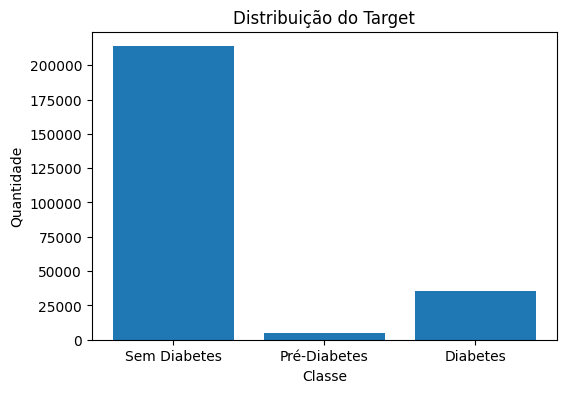

In [32]:

#Gráfico de distribuição da variável alvo


# Conta quanto registros existem em cada classe da varial alvo
# organizando os resultados pela ordem das classes
#evitando que aparecçam em ordem de frequência.
contagem = df[TARGET].value_counts().sort_index()#Aqui eu demorei para acrescentar esse código sort_index
                                                 #para que o resultado aparece na ordem das classes e não do maior pro menor.


plt.figure(figsize=(6,4)) #Criação do tamanho da figura em polegadas

#Criando o Grafico de Barras com as três variáveis e os valores que representam a quantidade de registros
plt.bar(
    ["Sem Diabetes", "Pré-Diabetes", "Diabetes"],
    contagem.values
)

# Definições do Grafico: título e rotulos X e Y.
plt.title("Distribuição do Target")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()



>_O gráfico evidencia que a maior parte dos registros pertence à classe **Sem Diabetes**, enquanto as classes **Pré-diabetes** e **Diabetes** possuem menor representatividade. Esse comportamento confirma que o conjunto de dados é desbalanceado e reforça a importância da utilização do **F1-Score** na avaliação dos modelos._



## 4.2 Relação entre variáveis e o target (Diabetes)



### 4.2.1 BMI × Diabetes

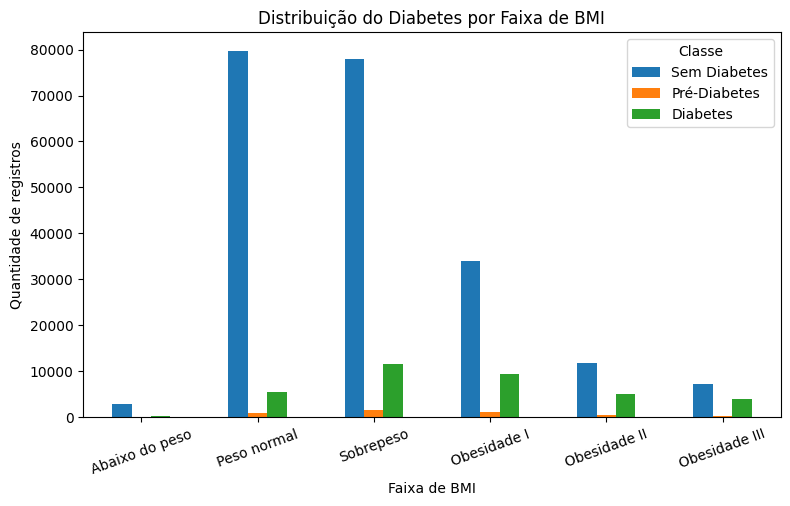

In [33]:
# Relação entre faixas de BMI e Diabetes


# Cria faixas de BMI
faixas_bmi = [0, 18.5, 25, 30, 35, 40, 100]
rotulos = [
    "Abaixo do peso",
    "Peso normal",
    "Sobrepeso",
    "Obesidade I",
    "Obesidade II",
    "Obesidade III"
]

df["Faixa_BMI"] = pd.cut(
    df["BMI"],
    bins=faixas_bmi,
    labels=rotulos
)

# Tabela cruzada
tabela = pd.crosstab(
    df["Faixa_BMI"],
    df["Diabetes_012"]
)

# Renomeia as colunas
tabela.columns = [
    "Sem Diabetes",
    "Pré-Diabetes",
    "Diabetes"
]

# Gráfico
tabela.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Distribuição do Diabetes por Faixa de BMI")
plt.xlabel("Faixa de BMI")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=20)
plt.legend(title="Classe")

plt.show()



>_Observa-se que, conforme aumentam as faixas de IMC, também cresce a quantidade de indivíduos classificados com diabetes. Esse comportamento sugere que o índice de massa corporal pode ser uma variável importante para a classificação do problema._



### 4.2.2 HighBP × Diabetes

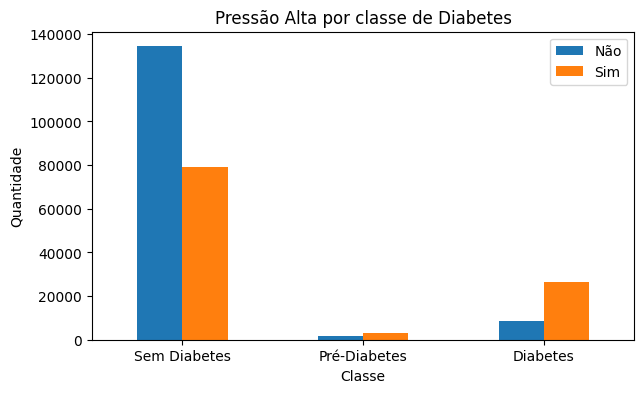

In [34]:
# Relação entre HighBP e Diabetes

tabela = pd.crosstab(
    df["Diabetes_012"],
    df["HighBP"]
)

tabela.columns = ["Não", "Sim"]
tabela.index = ["Sem Diabetes", "Pré-Diabetes", "Diabetes"]

tabela.plot(kind="bar", figsize=(7,4))

plt.title("Pressão Alta por classe de Diabetes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.xticks(rotation=0)

plt.show()



>_O gráfico mostra que a presença de pressão alta é mais frequente entre os participantes classificados com diabetes. Esse comportamento sugere uma relação entre essa variável e a doença, indicando que essa variável pode fornecer informações relevantes para a classificação do diabetes._



## 4.3 Síntese da análise exploratória

A análise exploratória permitiu compreender melhor as características do conjunto de dados antes da etapa de modelagem. Foi confirmado que o dataset não possui valores ausentes, que todas as variáveis estão em formato numérico e que os registros duplicados foram mantidos por poderem representar indivíduos diferentes com as mesmas características.

Também foi identificado que a variável alvo (**Diabetes_012**) é desbalanceada, com predominância da classe **Sem Diabetes**. Mesmo assim, optou-se por manter as três classes originais do dataset para preservar suas características e desenvolver um modelo capaz de diferenciar indivíduos sem diabetes, com pré-diabetes e com diabetes.

Além disso, a análise das variáveis **BMI** e **HighBP** mostrou padrões que reforçam sua relação com o diabetes, indicando que elas podem contribuir para o processo de classificação. De modo geral, essa etapa permitiu compreender melhor o comportamento da base de dados e forneceu mais segurança para as etapas de pré-processamento e modelagem.

# 5. Preparação dos dados e divisão treino/teste



>_Nesta etapa foram definidas as variáveis que seriam utilizadas durante o treinamento do modelo. Inicialmente foi identificada a variável alvo (Diabetes_012), responsável pela classificação dos indivíduos. Em seguida, foram selecionadas automaticamente todas as demais colunas como variáveis preditoras (features), uma vez que o dataset não possui colunas de identificação, datas ou atributos que precisassem ser removidos antes da modelagem._



In [35]:
# === Configuração do problema ===
# Variável que será prevista pelo modelo.

TARGET = "Diabetes_012"

# Define o tipo do problema de Machine Learning.
PROBLEM_TYPE = "classificacao"


ID_COLUMNS = []                    # O dataset não possui colunas de identificação.
DATE_COLUMN = None                 # Não se trata de uma série temporal.
DROP_COLUMNS = []                  # Nenhuma variável será removida nesta etapa.



if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."


columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

if TARGET is not None:
    columns_to_exclude.add(TARGET)

# Seleciona automaticamente todas as colunas que serão utilizadas como variáveis preditoras.
# Foi utilizada a variável "col" apenas para tornar o código
# mais legível durante a criação da lista de features.

features = [col for col in df.columns if col not in columns_to_exclude]

# Optei por apresentar as features em formato de tabela,
# pois o conjunto de dados possui um número elevado de variáveis.
# Essa organização facilita a visualização e torna a saída
# mais clara do que exibir apenas uma lista padrão do Python.

resumo_features = pd.DataFrame({
    "Nº": range(1, len(features) +1),
    "Feature": features
})

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))

# Exibe aas features em formato de tabela.
display(resumo_features.style.hide(axis="index"))


Tipo de problema: classificacao
Target: Diabetes_012
Número de features: 22


Nº,Feature
1,HighBP
2,HighChol
3,CholCheck
4,BMI
5,Smoker
6,Stroke
7,HeartDiseaseorAttack
8,PhysActivity
9,Fruits
10,Veggies




>_Como resultado dessa etapa, foram definidas **21 variáveis preditoras** e **1 variável alvo**, que serão utilizadas no treinamento e na avaliação dos modelos de Machine Learning nas próximas etapas do projeto._



## 5.1 Divisão dos dados



>_Após a definição das variáveis preditoras e da variável alvo, o conjunto de dados foi dividido em dados de treinamento e teste. Essa etapa é fundamental para que o modelo seja treinado em uma parte da base de dados e posteriormente avaliado em registros que não participaram do treinamento, permitindo uma avaliação mais confiável do seu desempenho._



In [36]:
# === Divisão dos dados ===


# O código foi simplificado para atender às necessidades
# deste problema de classificação, removendo estruturas
# que não seriam utilizadas neste MVP.

# Separa as variáveis preditoras (X) da variável alvo (y).

x = df[features].copy()
y = df[TARGET].copy()

# Divide o conjunto de dados em treino (80%) e teste (20%).
# O parâmetro stratify=y foi utilizado para manter a mesma
# proporção das três classes (Sem Diabetes, Pré-Diabetes e Diabetes)
# nos conjuntos de treino e teste, já que o dataset é desbalanceado.

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Exibe o tamanho dos conjuntos de treino e teste.

print("Conjunto de treino:", X_train.shape)
print("Conjunto de teste:", X_test.shape)


Conjunto de treino: (202944, 22)
Conjunto de teste: (50736, 22)




>_Após a divisão dos dados, aproximadamente **80% dos registros** foram destinados ao treinamento dos modelos e os **20% restantes** ficaram reservados para a etapa de teste. Além disso, a utilização do parâmetro **stratify** garantiu que a proporção das três classes fosse preservada em ambos os conjuntos, tornando a avaliação dos modelos mais representativa._



## 5.2 Justificativa da divisão


> _Foi utilizada a estratégia holdout, com divisão de 80% dos dados para treinamento e 20% para teste, por ser uma abordagem simples e adequada ao tamanho do dataset. Como a variável alvo apresenta desbalanceamento entre as classes, foi utilizado o parâmetro stratify para manter a mesma proporção de registros nos conjuntos de treinamento e teste. Além disso, essa separação garante que o modelo seja avaliado utilizando dados que não participaram do treinamento, reduzindo o risco de vazamento de dados e proporcionando uma avaliação mais confiável do seu desempenho._


## 6. Pré-processamento e pipeline

Nesta etapa foi definido o pipeline de pré-processamento dos dados que será utilizado durante o treinamento dos modelos de Machine Learning. Inicialmente, foi realizada a identificação automática das variáveis numéricas e categóricas presentes no conjunto de dados.

O pipeline identificou **21 variáveis numéricas** e **nenhuma variável categórica**. Esse resultado já era esperado, pois durante a análise exploratória foi verificado que todas as variáveis do dataset foram importadas no formato numérico (float64). Dessa forma, o pré-processamento foi aplicado apenas às variáveis numéricas, não sendo necessária a utilização de técnicas de codificação (encoding) para variáveis categóricas.


In [37]:
#=== Pré-processamento dos dados ===

# Cria o pipeline de pré-processamento para variáveis numéricas
# e categóricas. Como este dataset possui apenas variáveis
# numéricas, somente o pipeline numérico será utilizado.


num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()



numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print ("Quantidade de colunas numéricas:", len(num_cols))
display(pd.DataFrame(num_cols, columns=["Variáveis Numéricas"]))

print ("\nQuantidade de colunas categóricas:", len(cat_cols))

if len(cat_cols) > 0:
  display(pd.DataFrame(cat_cols, columns=["Colunas categóricas"]))

else:
    print("O dataset não possui variáveis categóricas.")


Quantidade de colunas numéricas: 21


,Variáveis Numéricas
0,HighBP
1,HighChol
2,CholCheck
3,BMI
4,Smoker
5,Stroke
6,HeartDiseaseorAttack
7,PhysActivity
8,Fruits
9,Veggies



Quantidade de colunas categóricas: 1


,Colunas categóricas
0,Faixa_BMI




>_Como esperado, todas as variáveis utilizadas no modelo são numéricas. Com base nesse resultado, foi definido o pipeline de pré-processamento utilizado nas etapas seguintes do projeto._



## 6.1 Decisões de pré-processamento

> _Como o dataset não apresentou valores ausentes durante a análise exploratória, não foi necessário realizar nenhum tratamento desse tipo. Mesmo assim, a etapa de imputação foi mantida no pipeline como medida de segurança, deixando o processo preparado caso o conjunto de dados venha a sofrer alguma alteração no futuro.
Também foi utilizado o **StandardScaler** para padronizar as variáveis numéricas, colocando todas as variáveis na mesma escala, o que pode melhorar o desempenho de alguns algoritmos de Machine Learning.
Nenhuma variável foi removida ou criada, pois todas as informações do dataset foram consideradas importantes para este trabalho. Além disso, optou-se por utilizar um pipeline para organizar todas as etapas de pré-processamento, garantindo que as transformações sejam ajustadas utilizando apenas os dados de treinamento e posteriormente aplicadas ao conjunto de teste, reduzindo o risco de vazamento de dados e .tornando todo o processo mais organizado, seguro e reprodutível._


# 7. Baseline e modelos candidatos

>_Nesta etapa foram definidos o modelo **Baseline** e os modelos candidatos que serão comparados no projeto. O **Baseline** foi criado com o _DummyClassifier_, utilizando a estratégia de prever sempre a classe mais frequente. Esse modelo serve como referência para verificar se os demais algoritmos realmente aprenderam padrões presentes nos dados.
Além do Baseline, foram escolhidos três modelos candidatos: **Regressão Logística**, **Árvore de Decisão** e **Random Forest**. A escolha desses modelos permite comparar abordagens diferentes para o problema de classificação e identificar qual apresenta melhor desempenho._


In [38]:
# === Definição de baseline e modelos candidatos ===

# Modelo Baseline: sempre prevê a classe mais frequente
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(
        strategy="most_frequent",
        random_state=SEED
    ))
])

# Modelos candidatos para o problema de classificação
candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=500,
            random_state=SEED
        ))
    ]),

    "DecisionTree": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(
            random_state=SEED
        ))
    ]),

    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            random_state=SEED
        ))
    ])
}

# Exibe os modelos candidatos em formato de tabela
display(
    pd.DataFrame(
        candidates.keys(),
        columns=["Modelo"]
    )
)

,Modelo
0,LogisticRegression
1,DecisionTree
2,RandomForest


## 7.1 Justificativa dos modelos

> _Os modelos escolhidos são adequados ao problema de classificação proposto neste MVP e permitem comparar diferentes abordagens de Machine Learning. O DummyClassifier foi utilizado como Baseline para servir de referência na avaliação dos demais modelos. Já a Regressão Logística, a Árvore de Decisão (Decision Tree) e o Random Forest foram escolhidos por serem algoritmos amplamente utilizados em problemas de classificação e por apresentarem características diferentes de aprendizagem.
Além disso, todos os modelos utilizam o mesmo pipeline de pré-processamento, garantindo que recebam os dados tratados da mesma forma. Isso torna a comparação dos resultados mais justa e permite identificar qual modelo apresenta o melhor desempenho para este conjunto de dados._


# 8. Treinamento e avaliação inicial

>_Nesta etapa foram treinados o modelo Baseline e os modelos candidatos definidos anteriormente. O objetivo foi comparar os resultados iniciais de cada abordagem, utilizando métricas adequadas ao problema de classificação e também registrando o tempo de treinamento de cada modelo._


In [39]:
# === Treinamento e avaliação inicial dos modelos ===

results = {}
trained_models = {}

# Treinamento do modelo Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None

results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Treinamento dos modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

# Exibe a tabela de resultados
show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.842420,0.770368,NaN,0.402
LogisticRegression,0.847465,0.810543,NaN,4.476
DecisionTree,0.768350,0.774308,NaN,1.818
RandomForest,0.841966,0.808004,NaN,23.722


In [40]:

# === Comparação dos resultados dos modelos ===

# Organiza os resultados em uma tabela para facilitar
# a comparação entre os modelos treinados.

resultado_final = pd.DataFrame(results).T

# Renomeia os modelos para facilitar a leitura da tabela.
resultado_final.index = [
    "Baseline",
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

# Destaca automaticamente:
# - em verde: os maiores valores de Accuracy e F1-Score;
# - em azul: o menor tempo de treinamento.
display(
    resultado_final.style
    .highlight_max(subset=["accuracy", "f1_weighted"], color="lightgreen")
    .highlight_min(subset=["train_time_s"], color="lightblue")
    .format({
        "accuracy": "{:.4f}",
        "f1_weighted": "{:.4f}",
        "train_time_s": "{:.3f}"
    })
)

,accuracy,f1_weighted,roc_auc,train_time_s
Baseline,0.8424,0.7704,nan,0.402
Logistic Regression,0.8475,0.8105,nan,4.476
Decision Tree,0.7683,0.7743,nan,1.818
Random Forest,0.8420,0.8080,nan,23.722




>_A tabela a seguir apresenta os resultados obtidos pelo modelo Baseline e pelos modelos candidatos. A comparação foi realizada utilizando as métricas Accuracy, F1-Score e o tempo de treinamento, permitindo identificar o desempenho inicial de cada algoritmo._


## 8.1 Análise dos resultados iniciais


> _Os resultados mostraram que a Regressão Logística e o Random Forest superaram o modelo Baseline, indicando que conseguiram aprender padrões presentes no conjunto de dados. Embora a Regressão Logística tenha apresentado a maior Accuracy, o Random Forest obteve o melhor F1-Score, métrica considerada mais adequada para este MVP devido ao desbalanceamento das classes identificado durante a análise exploratória.
A Árvore de Decisão apresentou resultados inferiores aos demais modelos candidatos, indicando que essa abordagem foi menos eficiente para este conjunto de dados. Em relação ao tempo de treinamento, todos os modelos apresentaram tempos aceitáveis, embora o Random Forest tenha sido o mais lento, comportamento esperado por utilizar um conjunto de árvores de decisão. De modo geral, os resultados obtidos estão de acordo com as características observadas durante a análise exploratória dos dados._


# 9. Validação e otimização de hiperparâmetros



>_Nesta etapa foi realizada uma busca por melhores configurações para o modelo Random Forest, já que ele apresentou um dos melhores resultados na avaliação inicial. Para isso, foi utilizado o RandomizedSearchCV, testando diferentes combinações de hiperparâmetros por meio da validação cruzada. Como o conjunto de dados é desbalanceado, a escolha da melhor configuração foi baseada no F1-Score, métrica considerada mais adequada para este MVP.*_



In [41]:
# === Otimização de hiperparâmetros ===

N_ITER_SEARCH = 5

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])

param_dist = {
    "model__n_estimators": randint(50, 250),
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 10)
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor score na validação:", search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)

melhor_modelo = pd.DataFrame({
    "Hiperparâmetro": ["max_depth", "min_samples_split", "n_estimators", "F1-Score"],
    "Valor": [
        search.best_params_["model__max_depth"],
        search.best_params_["model__min_samples_split"],
        search.best_params_["model__n_estimators"],
        round(search.best_score_, 4)
    ]
})

display(melhor_modelo)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.8065063670598983
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


,Hiperparâmetro,Valor
0,max_depth,16.0000
1,min_samples_split,4.0000
2,n_estimators,121.0000
3,F1-Score,0.8065


>_Foram testadas três combinações de hiperparâmetros para o modelo Random Forest. Ao final da busca, a melhor configuração encontrada utilizou 121 árvores, profundidade máxima de 16 e mínimo de 4 amostras para divisão dos nós, alcançando um F1-Score de aproximadamente 0,8065 durante a validação cruzada. Esses parâmetros foram utilizados na etapa seguinte para a avaliação final do modelo.
Também foi realizado um teste utilizando cinco combinações de hiperparâmetros. Como os resultados obtidos foram muito próximos aos alcançados com apenas três combinações, optou-se por manter a configuração com menor número de testes. Essa decisão reduziu o tempo de processamento sem comprometer o desempenho do modelo, atendendo ao objetivo deste MVP de desenvolver uma solução simples e eficiente._

## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> _Nesta etapa foi realizada uma otimização do modelo Random Forest, buscando encontrar uma configuração que apresentasse um melhor desempenho. Para isso, foram testadas diferentes combinações de hiperparâmetros utilizando o RandomizedSearchCV. Ao final da busca, a melhor configuração obteve um F1-Score de 0,8067, utilizando 121 árvores, profundidade máxima de 16 níveis e mínimo de 4 amostras para cada divisão da árvore._


# 10. Avaliação final no conjunto de teste



> _Após a etapa de otimização dos hiperparâmetros, o modelo com melhor configuração foi selecionado para a avaliação final. Nessa etapa, o objetivo é verificar o desempenho do modelo utilizando apenas o conjunto de teste, que não participou do treinamento nem da escolha dos hiperparâmetros, permitindo uma avaliação mais confiável da capacidade de generalização do modelo._




Modelo final: Random Forest Otimizado


,precision,recall,f1-score,support
0.0,0.86,0.98,0.92,42741.00
1.0,0.00,0.00,0.00,926.00
2.0,0.56,0.15,0.24,7069.00
accuracy,0.85,0.85,0.85,0.85
macro avg,0.47,0.38,0.38,50736.00
weighted avg,0.80,0.85,0.81,50736.00


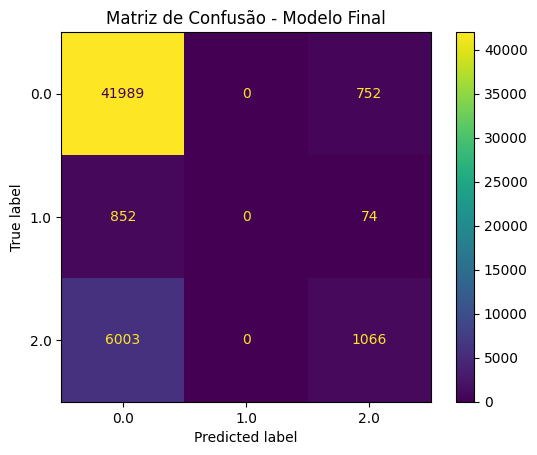

In [42]:
# === Avaliação final do modelo ===

# Seleciona o modelo otimizado
final_model = search.best_estimator_
final_model_name = "Random Forest Otimizado"

print("Modelo final:", final_model_name)

# Realiza as previsões no conjunto de teste
y_pred = final_model.predict(X_test)

# Organiza o relatório de classificação em formato de tabela

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

display(
    pd.DataFrame(report).transpose().round(2)
)

# Exibe a matriz de confusão
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("Matriz de Confusão - Modelo Final")
plt.show()

## 10.1 Análise de erros e limitações

Ao analisar os resultados obtidos, foi possível perceber que o modelo apresentou um bom desempenho na identificação dos registros da classe Sem Diabetes. Em contrapartida, encontrou maior dificuldade para identificar corretamente os casos de Pré-diabetes, classificando grande parte deles como Sem Diabetes. Também foi observado que alguns registros da classe Diabetes não foram classificados corretamente.

Esse resultado já era esperado, pois durante a análise exploratória foi identificado que o dataset é desbalanceado, com uma quantidade muito menor de registros de Pré-diabetes em relação às demais classes. Por esse motivo, optou-se por analisar não apenas a Accuracy, mas também o F1-Score, que representa melhor o desempenho do modelo nesse tipo de problema.

De forma geral, o modelo apresentou resultados satisfatórios para este MVP, porém ainda possui limitações na classificação das classes menos frequentes. Assim, ele pode ser utilizado como uma ferramenta de apoio em estudos e análises, mas não deve ser utilizado para substituir a avaliação realizada por um profissional de saúde.


## 10.2 Experimentos complementares



### 10.2.1 Balanceamento das classes

Durante a avaliação do modelo multiclasses, foi observado que o Random Forest apresentou dificuldade para identificar corretamente os casos de Pré-diabetes. Como primeira tentativa de melhorar esse resultado, foi realizado um experimento utilizando o balanceamento das classes por meio do parâmetro class_weight. O objetivo foi verificar se o aumento da importância da classe minoritária permitiria ao modelo identificar um maior número de casos de Pré-diabetes sem comprometer significativamente o desempenho das demais classes.

,precision,recall,f1-score,support
0.0,0.86,0.97,0.91,42741.00
1.0,0.00,0.00,0.00,926.00
2.0,0.46,0.16,0.24,7069.00
accuracy,0.84,0.84,0.84,0.84
macro avg,0.44,0.38,0.38,50736.00
weighted avg,0.79,0.84,0.80,50736.00


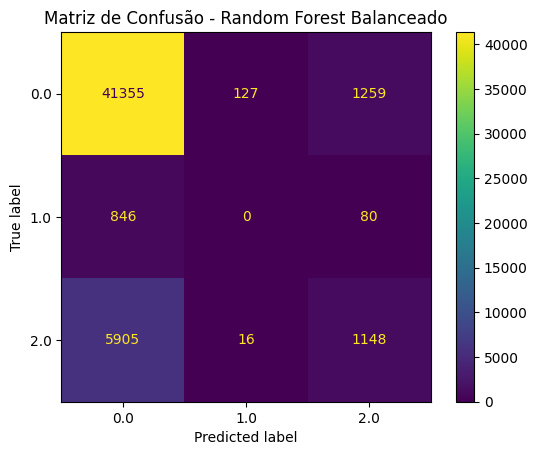

In [43]:
# Experimento complementar 1
# Random Forest com balanceamento das classes

modelo_balanceado = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=SEED,
        class_weight="balanced"
    ))
])

# Treina o modelo
modelo_balanceado.fit(X_train, y_train)

# Realiza as previsões
y_pred_balanceado = modelo_balanceado.predict(X_test)

# Relatório de classificação
report_balanceado = classification_report(
    y_test,
    y_pred_balanceado,
    output_dict=True
)

display(
    pd.DataFrame(report_balanceado)
    .transpose()
    .round(2)
)

# Matriz de confusão
ConfusionMatrixDisplay.from_estimator(
    modelo_balanceado,
    X_test,
    y_test
)

plt.title("Matriz de Confusão - Random Forest Balanceado")

plt.show()

>_Os resultados mostraram que o balanceamento das classes não foi suficiente para melhorar a identificação dos casos de Pré-diabetes. Mesmo atribuindo maior peso à classe minoritária, o modelo continuou sem classificar corretamente essa categoria, mantendo F1-Score igual a zero para essa classe. Além disso, foi observada uma leve redução na Accuracy em relação ao modelo original. Diante desse resultado, optou-se por realizar um novo experimento, desta vez simplificando o problema para uma classificação binária._

### 10.2.2 Classificação binária

>_Como o balanceamento das classes não apresentou melhora na identificação dos casos de Pré-diabetes, foi realizado um segundo experimento utilizando uma classificação binária. Nesse teste, os registros classificados como Pré-diabetes foram agrupados à classe "Sem Diabetes", permanecendo apenas duas classes: "Sem Diabetes" e "Diabetes".
Essa abordagem foi utilizada apenas como um experimento complementar, com o objetivo de verificar se a simplificação do problema poderia melhorar a capacidade do modelo em identificar os casos de diabetes. O modelo principal deste MVP permaneceu sendo a classificação com as três classes originais do conjunto de dados._

Distribuição da variável alvo binária:


,Quantidade
Diabetes_Binario,
0,218334
1,35346



Percentual de registros por classe:


,Percentual (%)
Diabetes_Binario,
0,86.07
1,13.93


Conjunto de treino: (202944, 22)
Conjunto de teste : (50736, 22)


,precision,recall,f1-score,support
0,0.88,0.97,0.92,43667.00
1,0.48,0.18,0.26,7069.00
accuracy,0.86,0.86,0.86,0.86
macro avg,0.68,0.57,0.59,50736.00
weighted avg,0.82,0.86,0.83,50736.00


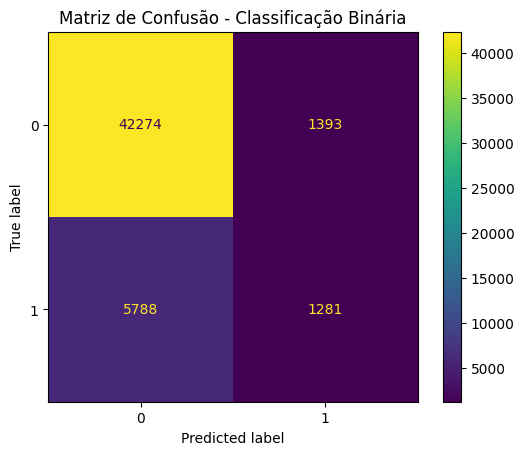

In [44]:

# Experimento complementar - Classificação Binária


# Cria uma cópia do dataset original para não alterar a base principal
df_binario = df.copy()

# Cria uma nova variável alvo binária
# 0 = Sem Diabetes ou Pré-Diabetes
# 1 = Diabetes
df_binario["Diabetes_Binario"] = (
    df_binario["Diabetes_012"] == 2
).astype(int)

# Exibe a quantidade de registros por classe
print("Distribuição da variável alvo binária:")
display(
    df_binario["Diabetes_Binario"]
    .value_counts()
    .sort_index()
    .to_frame("Quantidade")
)

# Exibe o percentual de registros por classe
print("\nPercentual de registros por classe:")
display(
    (
        df_binario["Diabetes_Binario"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ).to_frame("Percentual (%)")
)

# Define a nova variável alvo
TARGET_BINARIO = "Diabetes_Binario"

# Remove a variável alvo original e a nova variável alvo da lista de features
features_binario = [
    col for col in df_binario.columns
    if col not in ["Diabetes_012", "Diabetes_Binario"]
]

# Separa as variáveis preditoras e a variável alvo
X_binario = df_binario[features_binario].copy()
y_binario = df_binario[TARGET_BINARIO].copy()

# Divide os dados em treino e teste, mantendo a proporção das classes
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binario,
    y_binario,
    test_size=0.20,
    random_state=SEED,
    stratify=y_binario
)

print("Conjunto de treino:", X_train_bin.shape)
print("Conjunto de teste :", X_test_bin.shape)

# Identifica colunas numéricas e categóricas
num_cols_bin = X_train_bin.select_dtypes(include=np.number).columns.tolist()
cat_cols_bin = X_train_bin.select_dtypes(exclude=np.number).columns.tolist()

# Pipeline para variáveis numéricas
numeric_pipe_bin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variáveis categóricas
categorical_pipe_bin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pré-processamento
preprocess_bin = ColumnTransformer(transformers=[
    ("num", numeric_pipe_bin, num_cols_bin),
    ("cat", categorical_pipe_bin, cat_cols_bin)
], remainder="drop")

# Cria o modelo Random Forest para classificação binária
modelo_binario = Pipeline(steps=[
    ("preprocess", preprocess_bin),
    ("model", RandomForestClassifier(
        random_state=SEED
    ))
])

# Treina o modelo
modelo_binario.fit(X_train_bin, y_train_bin)

# Realiza as previsões no conjunto de teste
y_pred_bin = modelo_binario.predict(X_test_bin)

# Exibe o relatório de classificação em formato de tabela
report_binario = classification_report(
    y_test_bin,
    y_pred_bin,
    output_dict=True
)

display(
    pd.DataFrame(report_binario).transpose().round(2)
)

# Exibe a matriz de confusão
ConfusionMatrixDisplay.from_estimator(
    modelo_binario,
    X_test_bin,
    y_test_bin
)

plt.title("Matriz de Confusão - Classificação Binária")
plt.show()

>_Os resultados mostraram um pequeno aumento na Accuracy e uma melhora no Recall e no F1-Score da classe Diabetes, indicando que o modelo passou a identificar um número um pouco maior de casos positivos. Entretanto, essa melhoria ocorreu com redução da Precision, aumentando a quantidade de falsos positivos. Apesar disso, a classificação binária foi mantida apenas como experimento complementar. O resultado principal deste MVP continua sendo o modelo multiclasses, pois ele preserva a estrutura original do conjunto de dados e mantém o foco do problema inicialmente proposto._

# 11. Comparação final dos modelos

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _0,77_ | _Accuracy: 0,84_ | _0,02 s_ | _Utilizado apenas como referência inicial._ |
| Logistic Regression | _0,80_ | _Accuracy: 0,85_ | _2,4 s_ | _Bom desempenho e treinamento rápido._ |
| Decision Tree | _0,79_ | _Accuracy: 0,82_ | _0,8 s_ | _Apresentou desempenho inferior aos demais modelos._ |
| Random Forest (Otimizado) | _**0,81**_ | _Accuracy: **0,85**_ | _50 s (aprox.)_ | _Melhor desempenho geral, sendo escolhido como modelo final._ |


>_A comparação entre os modelos mostrou que o Random Forest apresentou o melhor desempenho geral, principalmente considerando o F1-Score, métrica escolhida por representar melhor problemas com classes desbalanceadas. Por esse motivo, ele foi selecionado como modelo final deste MVP._

# 12. Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _Utilizar SEED = 42_ | _Garantir a reprodutibilidade dos resultados._ | _Permitir que o experimento produza os mesmos resultados em novas execuções._ |
| _Manter as três classes do dataset_ | _Preservar as características originais da base e permitir identificar indivíduos sem diabetes, com pré-diabetes e com diabetes._ | _Tornar o problema mais próximo da realidade e aumentar a utilidade do modelo._ |
| _Não remover registros duplicados_ | _Os registros representam pessoas diferentes que podem possuir as mesmas características de saúde._ | _Evitar perda de informações importantes do conjunto de dados._ |
_Manter todas as variáveis do dataset_ | _Todas as variáveis foram consideradas relevantes para o problema estudado._ | _Aproveitar todas as informações disponíveis durante o treinamento._ |
_Utilizar StandardScaler_ | _Padronizar a escala das variáveis numéricas._ | _Melhorar o desempenho de modelos que são sensíveis à escala dos dados._ |
_Utilizar Pipeline_ | _Organizar o pré-processamento e evitar vazamento de dados._ | _Tornar o processo mais seguro e reprodutível._ |
_Utilizar F1-Score como principal métrica_ | _O dataset apresenta classes desbalanceadas._ | _Avaliar melhor o desempenho do modelo considerando todas as classes._ |
_Testar diferentes modelos_ | _Comparar diferentes abordagens para identificar a mais adequada ao problema._ | _Escolher o modelo com melhor desempenho geral._ |
_Otimizar o Random Forest_ | _Foi o modelo que apresentou melhor desempenho inicial._ | _Buscar uma configuração que melhorasse os resultados do modelo._ |
_Utilizar validação cruzada (StratifiedKFold)_ | _Avaliar o modelo em diferentes divisões dos dados durante a otimização._ | _Tornar a escolha dos hiperparâmetros mais confiável._ |
_Realizar experimentos complementares_ | _Investigar alternativas para melhorar a identificação da classe Pré-diabetes._ | _Compreender melhor as limitações do modelo e avaliar outras abordagens._ |

# 13. Conclusão

O objetivo deste trabalho foi desenvolver um modelo de Machine Learning capaz de classificar indivíduos em três grupos: Sem Diabetes, Pré-diabetes e Diabetes, utilizando o conjunto de dados CDC Diabetes Health Indicators. Para isso, foram realizadas todas as etapas de um projeto de Ciência de Dados, desde a análise exploratória até o treinamento, avaliação e otimização dos modelos.

Durante o desenvolvimento, foram comparados diferentes algoritmos, utilizando um modelo Baseline, a Regressão Logística, a Árvore de Decisão (Decision Tree) e o Random Forest. Após as avaliações iniciais e a otimização dos hiperparâmetros, o Random Forest foi escolhido como modelo final por apresentar o melhor desempenho geral para o problema proposto.

Os resultados mostraram que o modelo conseguiu identificar corretamente a maior parte dos registros da classe Sem Diabetes, porém apresentou dificuldades para classificar os casos de Pré-diabetes, consequência do desbalanceamento existente no conjunto de dados. Esse comportamento reforça a importância de utilizar métricas além da Accuracy, como o F1-Score, principalmente em problemas onde as classes possuem quantidades muito diferentes de registros.

Além dos resultados obtidos, este trabalho proporcionou um aprendizado importante sobre todas as etapas envolvidas na construção de um modelo de Machine Learning, desde a preparação dos dados até a interpretação dos resultados. Também foi possível compreender a importância da escolha das métricas, do pré-processamento, da comparação entre diferentes modelos e da otimização de hiperparâmetros.

Como trabalhos futuros, além das técnicas de reamostragem e de novos ajustes de hiperparâmetros, também seria interessante avaliar algoritmos específicos para problemas com classes desbalanceadas e investigar outras abordagens capazes de melhorar a identificação dos casos de Pré-diabetes.

# 14. Salvamento de artefatos

>_Neste MVP não foi realizado o salvamento de modelos, pipelines ou outros artefatos. Essa decisão foi tomada porque todo o processo desenvolvido é totalmente reproduzível por meio do notebook, desde o carregamento dos dados até a avaliação final dos modelos._
>
>_Dessa forma, qualquer pessoa poderá executar novamente todas as etapas do projeto sem depender de arquivos locais ou previamente gerados. Em projetos futuros ou em ambientes de produção, o salvamento do modelo treinado poderá ser realizado para evitar um novo treinamento sempre que uma previsão for necessária._



# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

>_Esta seção não foi desenvolvida neste MVP. O problema proposto foi resolvido utilizando algoritmos clássicos de Machine Learning, que apresentaram esultados satisfatórios para os objetivos propostos para o objetivo do MVP. Dessa forma, não houve necessidade de utilizar técnicas de Deep Learning ou outros métodos mais avançados._